In [1]:
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [2]:
data = pd.read_csv('/content/drive/MyDrive/FdeA _ 2026 -1/Insurance/medical_insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


# Entendimiento de negocio

Objetivo de negocio: ¿Es posible automatizar la definición del valor de un seguro médico?


Objetivo analítico: Crear un modelo de regresión que sea capaz de predecir el valor de un seguro médico.

# Entendimiento de los datos

Notebook de exploración de datos.

# Preparación de datos

Para este caso:

- Eliminar columnas irrelevantes.
- Imputación de datos nulos.
- Transformación de variables categóricas.
- Seperación de datos de entrenamiento y pruebas.
- Escalar datos.

In [5]:
# todas las variables son relevantes
# data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [6]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [8]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [9]:
# Al no tener datos nulos, no es necesario hacer imputación de datos
# imputer_median = SimpleImputer(strategy='median')
# imputer_mode = SimpleImputer(strategy='most_frequent')

In [10]:
# imputer_median.fit(data[['Age']])
# imputer_mode.fit(data[['Embarked']])

# data['Age'] = imputer_median.transform(data[['Age']])
# data['Embarked'] = imputer_mode.transform(data[['Embarked']]).flatten()

In [11]:
ordinal_encoder_sex = OrdinalEncoder()
ordinal_encoder_smoker = OrdinalEncoder()
onehot_encoder_region = OneHotEncoder(drop='first', sparse_output=False)

ordinal_encoder_sex.fit(data[['sex']])
ordinal_encoder_smoker.fit(data[['smoker']])
onehot_encoder_region.fit(data[['region']])

data['sex'] = ordinal_encoder_sex.transform(data[['sex']])
data['smoker'] = ordinal_encoder_smoker.transform(data[['smoker']])
data[onehot_encoder_region.get_feature_names_out()] = onehot_encoder_region.transform(data[['region']])

In [12]:
onehot_encoder_region.get_feature_names_out()

array(['region_northwest', 'region_southeast', 'region_southwest'],
      dtype=object)

In [13]:
data.drop(['region'], axis=1, inplace=True)

In [14]:
data.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0.0,27.900,0,1.0,16884.92400,0.0,0.0,1.0
1,18,1.0,33.770,1,0.0,1725.55230,0.0,1.0,0.0
2,28,1.0,33.000,3,0.0,4449.46200,0.0,1.0,0.0
3,33,1.0,22.705,0,0.0,21984.47061,1.0,0.0,0.0
4,32,1.0,28.880,0,0.0,3866.85520,1.0,0.0,0.0


In [15]:
data.mean()

,0
age,39.109668
sex,0.507215
bmi,30.701349
children,1.101732
smoker,0.203463
charges,13261.369959
region_northwest,0.239538
region_southeast,0.276335
region_southwest,0.246753


X: datos de entrada (input)

y: datos de salida (output)

In [37]:
X = data.drop('charges', axis=1)
y = np.log1p(data['charges']) # Applying logarithmic transformation to y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32)

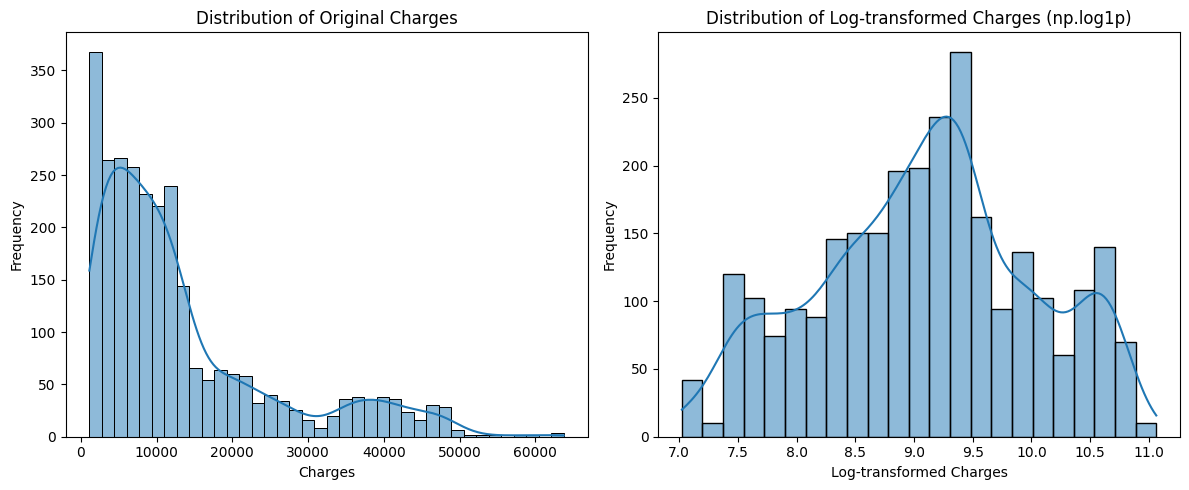

In [38]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data['charges'], kde=True)
plt.title('Distribution of Original Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(y, kde=True)
plt.title('Distribution of Log-transformed Charges (np.log1p)')
plt.xlabel('Log-transformed Charges')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [39]:
X_train.shape, X_test.shape, data.shape

((2217, 8), (555, 8), (2772, 9))

In [40]:
scaler = StandardScaler() # RESTA A LOS DATOS LA MEDIA Y LUEGO DIVIDE SOBRE LA DESVIACIÓN ESTANDAR
# casi todos los datos van a estar entre -3 y 3 y una propiedad que se va a cumplir de manera obligatoria es que la media será 0 y la std será 1
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Modelación

- Simulación con diferentes modelos.
- Búsqueda y selección de hyper parámetros.

# Evaluación
- ¿Qué tan bien lo hizo cada modelo?
- Definición de mejor modelo.
- Variables de mayor importancia.

Positivo: sobrevivir
Negativo: fallecer

In [19]:
data.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0.0,27.900,0,1.0,16884.92400,0.0,0.0,1.0
1,18,1.0,33.770,1,0.0,1725.55230,0.0,1.0,0.0
2,28,1.0,33.000,3,0.0,4449.46200,0.0,1.0,0.0
3,33,1.0,22.705,0,0.0,21984.47061,1.0,0.0,0.0
4,32,1.0,28.880,0,0.0,3866.85520,1.0,0.0,0.0



--- Linear Regression ---
Best Linear Regression Model: LinearRegression()
Training MAE (Linear Regression): 4133.8140
Training RMSE (Linear Regression): 5999.3860
Training R2 Score (Linear Regression): 0.7536
Test MAE (Linear Regression): 4160.2480
Test RMSE (Linear Regression): 6319.2717
Test R2 Score (Linear Regression): 0.7398

--- Feature Importance (Linear Regression Coefficients) ---
            Feature  Coefficient
4            smoker  9714.256450
0               age  3544.758928
2               bmi  1991.759273
3          children   550.173312
1               sex   -35.968296
5  region_northwest  -174.490095
7  region_southwest  -457.336541
6  region_southeast  -511.824338

--- SHAP Values (Linear Regression) ---

Waterfall Plot for a single instance (first in test set):


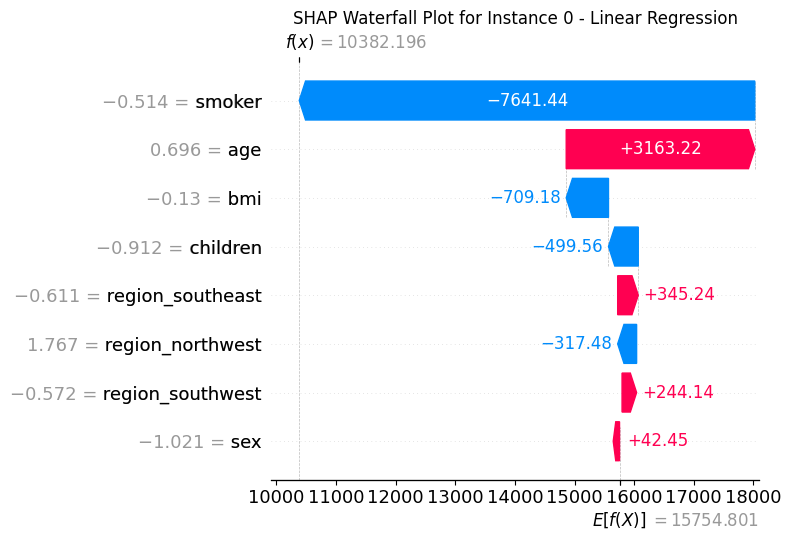

In [24]:
print("\n--- Linear Regression ---")
linear_reg_model = LinearRegression() # Replaced LogisticRegression
param_grid_linear_reg = {
    'fit_intercept': [True, False] # Example parameter for GridSearchCV with LinearRegression
}

grid_search_linear_reg = GridSearchCV(linear_reg_model, param_grid_linear_reg, cv=5, scoring='r2', n_jobs=-1) # Changed scoring
grid_search_linear_reg.fit(X_train, y_train)

best_linear_reg = grid_search_linear_reg.best_estimator_
print(f"Best Linear Regression Model: {best_linear_reg}")

y_train_pred_linear_reg = best_linear_reg.predict(X_train)
y_test_pred_linear_reg = best_linear_reg.predict(X_test)

# Changed evaluation metrics to MAE, RMSE, and R2_score for regression
print(f"Training MAE (Linear Regression): {mean_absolute_error(y_train, y_train_pred_linear_reg):.4f}")
print(f"Training RMSE (Linear Regression): {root_mean_squared_error(y_train, y_train_pred_linear_reg):.4f}")
print(f"Training R2 Score (Linear Regression): {r2_score(y_train, y_train_pred_linear_reg):.4f}")

print(f"Test MAE (Linear Regression): {mean_absolute_error(y_test, y_test_pred_linear_reg):.4f}")
print(f"Test RMSE (Linear Regression): {root_mean_squared_error(y_test, y_test_pred_linear_reg):.4f}")
print(f"Test R2 Score (Linear Regression): {r2_score(y_test, y_test_pred_linear_reg):.4f}")

# Removed confusion matrix as it's for classification

print("\n--- Feature Importance (Linear Regression Coefficients) ---")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_linear_reg.coef_
}).sort_values(by='Coefficient', ascending=False)
print(feature_importance)

print("\n--- SHAP Values (Linear Regression) ---")

# Using shap.LinearExplainer for linear models
explainer = shap.LinearExplainer(best_linear_reg, X_train, feature_names=X.columns) # Added feature_names

shap_values = explainer(X_test)

print("\nWaterfall Plot for a single instance (first in test set):")
shap.plots.waterfall(shap_values[0], max_display=10, show=False)
plt.title('SHAP Waterfall Plot for Instance 0 - Linear Regression')
plt.tight_layout()
plt.show()


--- Decision Tree Regressor ---
Best Decision Tree Regressor Model: DecisionTreeRegressor(max_depth=20, random_state=42)

--- Evaluation on Log-transformed Scale ---
Training MAE (Decision Tree Regressor): 0.0033
Training RMSE (Decision Tree Regressor): 0.0604
Training R2 Score (Decision Tree Regressor): 0.9958
Test MAE (Decision Tree Regressor): 0.0479
Test RMSE (Decision Tree Regressor): 0.2318
Test R2 Score (Decision Tree Regressor): 0.9340

--- Evaluation on Original Scale (Inverse Log Transform) ---
Training MAE (Decision Tree Regressor - Original Scale): 25.0225
Training RMSE (Decision Tree Regressor - Original Scale): 480.5638
Training R2 Score (Decision Tree Regressor - Original Scale): 0.9985
Test MAE (Decision Tree Regressor - Original Scale): 540.9490
Test RMSE (Decision Tree Regressor - Original Scale): 2562.8231
Test R2 Score (Decision Tree Regressor - Original Scale): 0.9517

--- Feature Importance (Decision Tree Regressor) ---
            Feature  Importance
4          

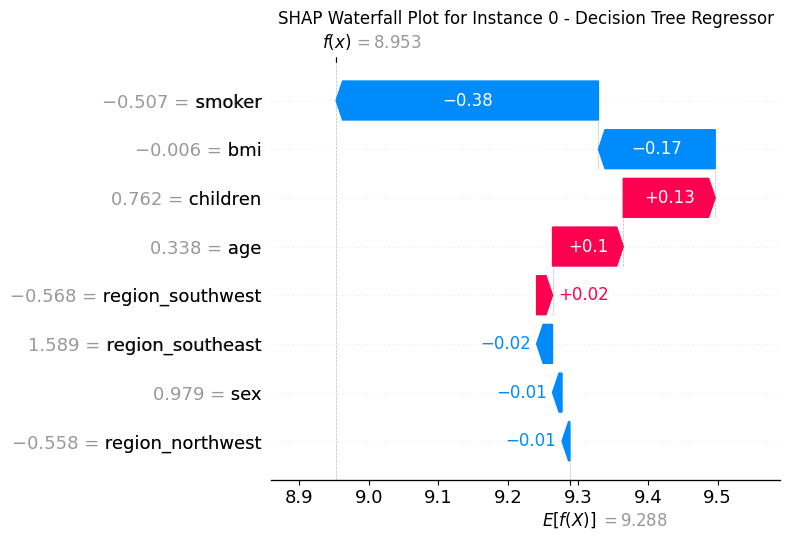

In [41]:
print("\n--- Decision Tree Regressor ---")
decision_tree_model = DecisionTreeRegressor(random_state=42)
param_grid_tree = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['squared_error', 'absolute_error'] # Changed criterion for regression
}

grid_search_tree = GridSearchCV(decision_tree_model, param_grid_tree, cv=5, scoring='r2', n_jobs=-1)
grid_search_tree.fit(X_train, y_train)

best_tree = grid_search_tree.best_estimator_
print(f"Best Decision Tree Regressor Model: {best_tree}")

y_train_pred_tree = best_tree.predict(X_train)
y_test_pred_tree = best_tree.predict(X_test)

# Original evaluation metrics on log-transformed scale
print("\n--- Evaluation on Log-transformed Scale ---")
print(f"Training MAE (Decision Tree Regressor): {mean_absolute_error(y_train, y_train_pred_tree):.4f}")
print(f"Training RMSE (Decision Tree Regressor): {root_mean_squared_error(y_train, y_train_pred_tree):.4f}")
print(f"Training R2 Score (Decision Tree Regressor): {r2_score(y_train, y_train_pred_tree):.4f}")

print(f"Test MAE (Decision Tree Regressor): {mean_absolute_error(y_test, y_test_pred_tree):.4f}")
print(f"Test RMSE (Decision Tree Regressor): {root_mean_squared_error(y_test, y_test_pred_tree):.4f}")
print(f"Test R2 Score (Decision Tree Regressor): {r2_score(y_test, y_test_pred_tree):.4f}")

# Inverse transform predictions and actual values for evaluation on original scale
y_train_original_scale = np.expm1(y_train)
y_test_original_scale = np.expm1(y_test)
y_train_pred_tree_original_scale = np.expm1(y_train_pred_tree)
y_test_pred_tree_original_scale = np.expm1(y_test_pred_tree)

print("\n--- Evaluation on Original Scale (Inverse Log Transform) ---")
print(f"Training MAE (Decision Tree Regressor - Original Scale): {mean_absolute_error(y_train_original_scale, y_train_pred_tree_original_scale):.4f}")
print(f"Training RMSE (Decision Tree Regressor - Original Scale): {root_mean_squared_error(y_train_original_scale, y_train_pred_tree_original_scale):.4f}")
print(f"Training R2 Score (Decision Tree Regressor - Original Scale): {r2_score(y_train_original_scale, y_train_pred_tree_original_scale):.4f}")

print(f"Test MAE (Decision Tree Regressor - Original Scale): {mean_absolute_error(y_test_original_scale, y_test_pred_tree_original_scale):.4f}")
print(f"Test RMSE (Decision Tree Regressor - Original Scale): {root_mean_squared_error(y_test_original_scale, y_test_pred_tree_original_scale):.4f}")
print(f"Test R2 Score (Decision Tree Regressor - Original Scale): {r2_score(y_test_original_scale, y_test_pred_tree_original_scale):.4f}")

print("\n--- Feature Importance (Decision Tree Regressor) ---")
feature_importance_tree = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_tree.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(feature_importance_tree)

print("\n--- SHAP Values (Decision Tree Regressor) --")

explainer_tree = shap.TreeExplainer(best_tree, X_train, feature_names=X.columns)

shap_values_tree = explainer_tree(X_test)

print("\nWaterfall Plot for a single instance (first in test set):")
shap.plots.waterfall(shap_values_tree[0], max_display=10, show=False)
plt.title('SHAP Waterfall Plot for Instance 0 - Decision Tree Regressor')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(best_tree,
          feature_names=X.columns.tolist(),
          class_names=['No Survived', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Decision Tree Visualization (best_tree)')
plt.show()


--- Random Forest Regressor ---
Best Random Forest Regressor Model: RandomForestRegressor(n_estimators=30, random_state=42)
Training MAE (Random Forest Regressor): 484.8977
Training RMSE (Random Forest Regressor): 1127.3061
Training R2 Score (Random Forest Regressor): 0.9913
Test MAE (Random Forest Regressor): 1318.2344
Test RMSE (Random Forest Regressor): 2878.1232
Test R2 Score (Random Forest Regressor): 0.9460

--- Feature Importance (Random Forest Regressor) ---
            Feature  Importance
4            smoker    0.630751
2               bmi    0.209966
0               age    0.123079
3          children    0.016108
5  region_northwest    0.005718
1               sex    0.005201
6  region_southeast    0.004851
7  region_southwest    0.004325

--- SHAP Values (Random Forest Regressor) --

Waterfall Plot for a single instance (first in test set):


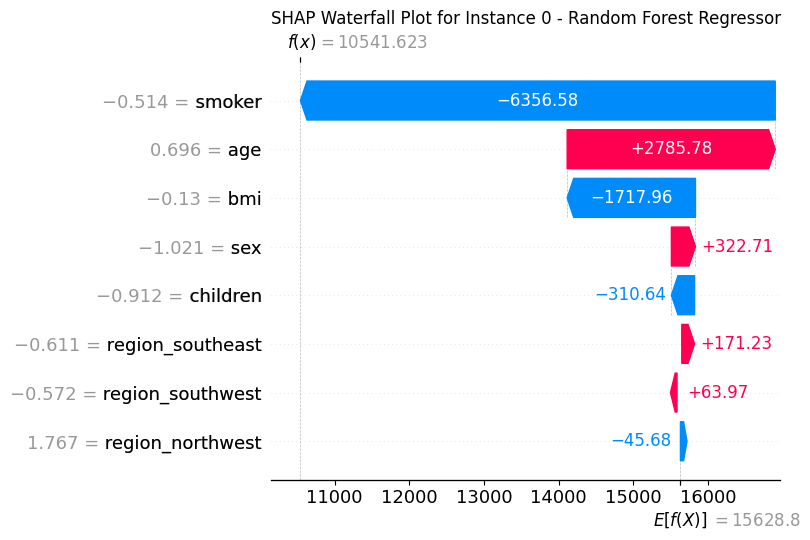

In [23]:
print("\n--- Random Forest Regressor ---")
random_forest_model = RandomForestRegressor(random_state=42)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 3, 7, 10,],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf = GridSearchCV(random_forest_model, param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

best_rf = grid_search_rf.best_estimator_
print(f"Best Random Forest Regressor Model: {best_rf}")

y_train_pred_rf = best_rf.predict(X_train)
y_test_pred_rf = best_rf.predict(X_test)

# Changed evaluation metrics to MAE, RMSE, and R2_score
print(f"Training MAE (Random Forest Regressor): {mean_absolute_error(y_train, y_train_pred_rf):.4f}")
print(f"Training RMSE (Random Forest Regressor): {root_mean_squared_error(y_train, y_train_pred_rf):.4f}")
print(f"Training R2 Score (Random Forest Regressor): {r2_score(y_train, y_train_pred_rf):.4f}")

print(f"Test MAE (Random Forest Regressor): {mean_absolute_error(y_test, y_test_pred_rf):.4f}")
print(f"Test RMSE (Random Forest Regressor): {root_mean_squared_error(y_test, y_test_pred_rf):.4f}")
print(f"Test R2 Score (Random Forest Regressor): {r2_score(y_test, y_test_pred_rf):.4f}")

# Removed confusion matrix as it's for classification

print("\n--- Feature Importance (Random Forest Regressor) ---")
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(feature_importance_rf)

print("\n--- SHAP Values (Random Forest Regressor) --")

# Removed model_output='probability' and adjusted for regression
explainer_rf = shap.TreeExplainer(best_rf, X_train, feature_names=X.columns)

shap_values_rf = explainer_rf(X_test, check_additivity=False)

print("\nWaterfall Plot for a single instance (first in test set):")
# Changed shap_values_rf[0, :, 1] to shap_values_rf[0] for regression
shap.plots.waterfall(shap_values_rf[0], max_display=10, show=False)
plt.title('SHAP Waterfall Plot for Instance 0 - Random Forest Regressor')
plt.tight_layout()
plt.show()

## ¿Cúal es el mejor modelo?

POsitivo: no está enferma
Negativo: está enferma


Waterfall Plot for a single instance (first in test set):


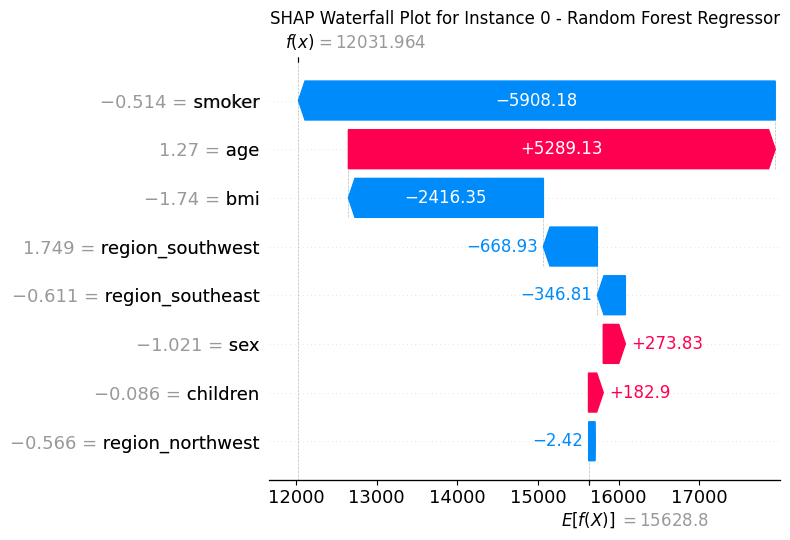

In [42]:
print("\nWaterfall Plot for a single instance (first in test set):")
# Changed shap_values_rf[0, :, 1] to shap_values_rf[0] for regression
shap.plots.waterfall(shap_values_rf[2], max_display=10, show=False)
plt.title('SHAP Waterfall Plot for Instance 0 - Random Forest Regressor')
plt.tight_layout()
plt.show()


Waterfall Plot for a single instance (first in test set):


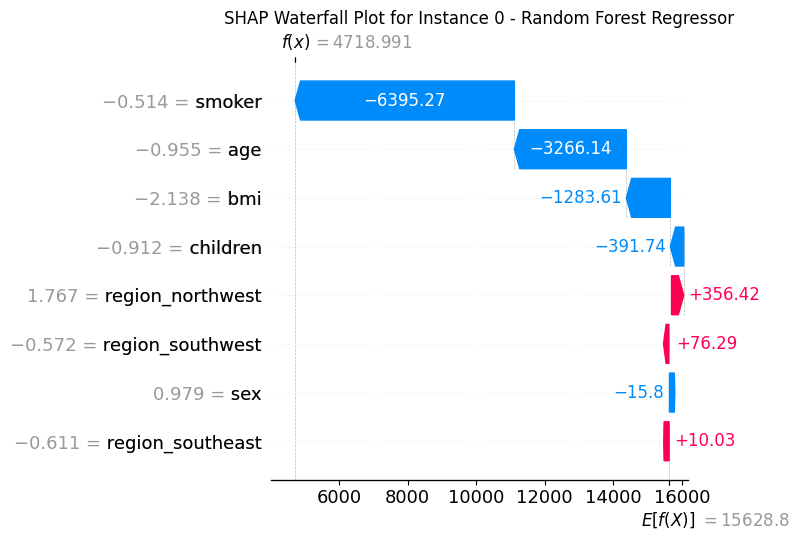

In [43]:
print("\nWaterfall Plot for a single instance (first in test set):")
# Changed shap_values_rf[0, :, 1] to shap_values_rf[0] for regression
shap.plots.waterfall(shap_values_rf[100], max_display=10, show=False)
plt.title('SHAP Waterfall Plot for Instance 0 - Random Forest Regressor')
plt.tight_layout()
plt.show()